# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Frank de Kogel| 6582737 |
| Casper Jansen| 6265200 |
| Owen van der Wal| 6545297 |
| Planning Groep: 26     |Tijdstip / Tijdspanne  |
|---|---|
| eerste samity check (werking apperatuur) | 10:55
| Tweede sanity check (bekende condensator) | 11:15 |
| Ontwerp eerste condensator gemaakt | 11:30 |
| Eerste condensator is gemaakt | 11:45 |
| derde sanity check (testen condensator check of werkt)|12:00
| pauze (middag) |12:45 tot 13:45
| ideeën brainstorm en kiezen welke we maken | 14:05|
| ontwerpen | 14:30 |
| fabriceren | 15:30 |
| Testen / meten, code schrijven| 16:30|
| opruimen, dubbel checks etc.|17:30|
| klaar(hopelijk)

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="processed-6941CD89-B727-4F63-BE09-B4359C1D7C20.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

def vlakkeplaat(A, d, epsilonZero):
    C = (A * epsilonZero) / d # Afkomstig van 2.54
    return C


# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = vlakkeplaat(0.01,0.2e-3,8.854*3.3e-12) * 1e12
print(f"Berekende capaciteit plaatcondensator groep 26 is {C:.1f} pF")



Berekende capaciteit plaatcondensator groep 26 is 1460.9 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](20260225_155944.jpg)
![scope meting 2](processed-E765A32B-BF11-4E48-9600-0E5E75638407.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 26| 1461 pF | 2.40 V | 1.925V | 1171 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](processed-EF690B51-9A68-4A07-91A1-C68174AD1683.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die de afstand meet door een dun voorwerp tussen de twee platen heen en weer te schuiven.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](processed-DB175DD1-093A-4ADD-B2DA-4886F2D182B9.jpeg)

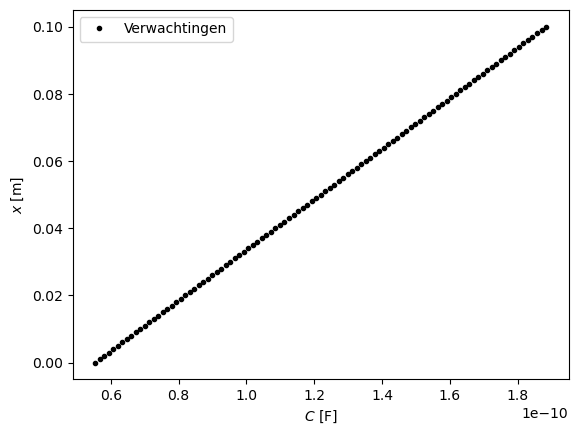

In [3]:
import numpy as np
import matplotlib.pyplot as plt

er_lucht = 1.0
er_pvc = 4.0

def c_from_x(x, Er_plastic):
    A_pvc = (8e-2)*x
    A_air = A_tot-A_pvc
    C = C0 * ((A_pvc*er_pvc+A_air*er_lucht)/(A_tot*er_lucht))
    return C*1e-12


#total area in capacitor
A_tot = 0.01

#make var for area from pvc
x = (np.linspace(0,100,101)*1e-3)

C0 = 55.4

#area air


#expected capacitance in pF
C = c_from_x(x, er_pvc)

plt.plot(C, np.linspace(0,100,101)*1e-3, 'k.', label='Verwachtingen')
plt.xlabel('$C$ [F]')
plt.ylabel('$x$ [m]')
plt.legend()
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 55 pF | 540 mV |
| gemiddelde capaciteit| 78,5 pF |800 mV|
| maximale capaciteit| 102 pF |1023 mV |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](1000025036.jpg)
![meting 2](1000025037.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

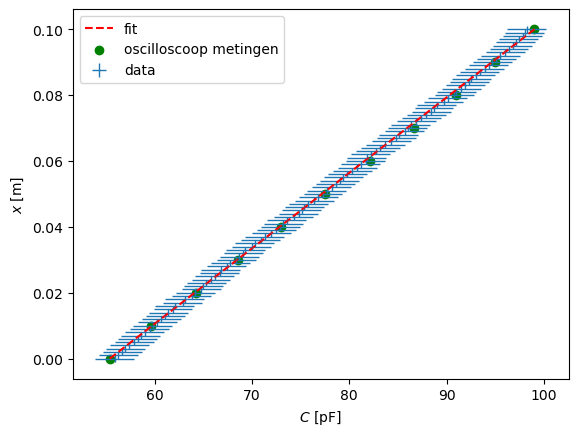

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
afstanden = np.linspace(0,100,101)*1e-3
capaciteiten = np.array([55.9,56.3,56.7,57.0,57.4,57.9,58.3,58.6,59.0,59.5,59.8,60.3,60.7,61.1,61.4,61.9,62.1,62.9,63.1,63.8,64.2,64.8,65.0,65.3,65.8,66.2,66.7,66.8,67.4,67.8,68.4,68.7,69.1,69.3,70.0,70.3,70.9,71.3,72.0,72.5,72.9,73.2,73.6,74.3,74.8,75.1,75.4,75.8,76.4,76.8,77.3,77.7,78.2,78.6,79.0,79.4,79.8,80.3,80.8,81.2,81.7,81.8,82.2,82.7,83.2,83.7,84.3,84.8,85.1,85.7,86.0,86.3,86.9,87.4,87.9,88.4,88.7,89.0,89.7,90.1,90.8,91.0,91.5,91.9,92.3,92.5,93.0,93.4,93.9,94.3,94.7,95.1,95.5,96.0,96.4,96.8,97.1,97.4,97.8,98.0,98.2])
oscilloscoopMetingen = np.array([55.4, 59.6, 64.3, 68.6, 73.0, 77.5, 82.1, 86.6, 91.0, 95.0, 99.0])


def c_from_x(x, Er):
    A_pvc = (8e-2)*x
    A_air = A_tot-A_pvc
    C = C0 * ((A_pvc*Er+A_air*er_lucht)/(A_tot*er_lucht))
    return C


popt,pcov = curve_fit(c_from_x,afstanden,capaciteiten)
ytest = np.linspace(np.min(afstanden),np.max(afstanden),100)
xtest = c_from_x(ytest,popt[0])

plt.figure()                                                                                                           # 2 piocofarad onzekerheid komt van schommelingen van arduino
plt.errorbar(capaciteiten,afstanden,xerr=2,yerr=1e-3,linewidth=0,marker='.',markersize=0.5, elinewidth=1,label='data') # 1mm onzekerheid komt van 1mm streepjes op stuk plastic
plt.plot(xtest,ytest,'r--',label='fit')
plt.scatter(oscilloscoopMetingen, np.linspace(0, 100e-3, 11), color='green', label='oscilloscoop metingen')
plt.xlabel('$C$ [pF]')
plt.ylabel('$x$ [m]')
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* de afstand tussen de twee platen minimaliseren, dit heeft invloed op de capiciteit.
* Het materiaal van het geleidende stuk tussen de twee platen veranderen naar een materiaal met een hogere dielelektricum.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](20260225_155944.jpg)

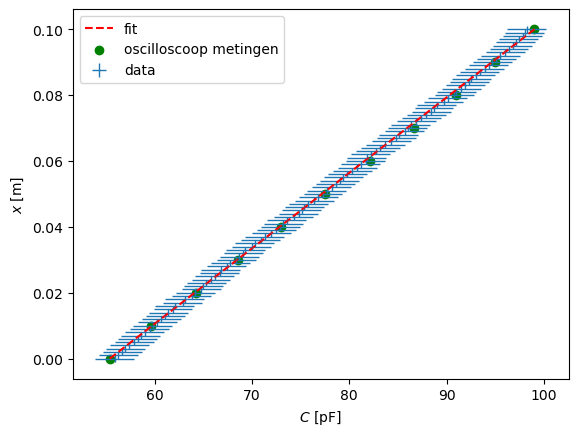

Onzekerheid van x is eerder bepaald via een lineaire fit op 0.3mm


In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
afstanden = np.linspace(0,100,101)*1e-3
capaciteiten = np.array([55.9,56.3,56.7,57.0,57.4,57.9,58.3,58.6,59.0,59.5,59.8,60.3,60.7,61.1,61.4,61.9,62.1,62.9,63.1,63.8,64.2,64.8,65.0,65.3,65.8,66.2,66.7,66.8,67.4,67.8,68.4,68.7,69.1,69.3,70.0,70.3,70.9,71.3,72.0,72.5,72.9,73.2,73.6,74.3,74.8,75.1,75.4,75.8,76.4,76.8,77.3,77.7,78.2,78.6,79.0,79.4,79.8,80.3,80.8,81.2,81.7,81.8,82.2,82.7,83.2,83.7,84.3,84.8,85.1,85.7,86.0,86.3,86.9,87.4,87.9,88.4,88.7,89.0,89.7,90.1,90.8,91.0,91.5,91.9,92.3,92.5,93.0,93.4,93.9,94.3,94.7,95.1,95.5,96.0,96.4,96.8,97.1,97.4,97.8,98.0,98.2])
oscilloscoopMetingen = np.array([55.4, 59.6, 64.3, 68.6, 73.0, 77.5, 82.1, 86.6, 91.0, 95.0, 99.0])


def c_from_x(x, Er):
    A_pvc = (8e-2)*x
    A_air = A_tot-A_pvc
    C = C0 * ((A_pvc*Er+A_air*er_lucht)/(A_tot*er_lucht))
    return C

popt,pcov = curve_fit(c_from_x,afstanden,capaciteiten)
ytest = np.linspace(np.min(afstanden),np.max(afstanden),100)
xtest = c_from_x(ytest,popt[0])

plt.figure()                                                                                                           # 2 piocofarad onzekerheid komt van schommelingen van arduino
plt.errorbar(capaciteiten,afstanden,xerr=2,yerr=1e-3,linewidth=0,marker='.',markersize=0.5, elinewidth=1,label='data') # 1mm onzekerheid komt van 1mm streepjes op stuk plastic
plt.plot(xtest,ytest,'r--',label='fit')
plt.scatter(oscilloscoopMetingen, np.linspace(0, 100e-3, 11), color='green', label='oscilloscoop metingen')
plt.xlabel('$C$ [pF]')
plt.ylabel('$x$ [m]')
plt.legend()
plt.show()
print("Onzekerheid van x is eerder bepaald via een lineaire fit op 0.3mm")
# Aangepast is dat in de arduino software nu een afstand in meters wordt gereturned, omdat het systeem al dermate precies was dat er nog weinig iteratie nodig was

## Opdracht 10: Vul hieronder de conclusie in.

Wij hebben door middel van een condensator een sensor geproduceerd die in staat is lineaire verplaatsing te bepalen met een precisie van +- 0.3mm, met een bereik van 0 tot 100 mm. De resolutie is 1 mm.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

### kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](20260225_155944.jpg)
![scope meting 2](processed-E765A32B-BF11-4E48-9600-0E5E75638407.jpeg)

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 55 pF | 540 mV |
| gemiddelde capaciteit| 78,5 pF |800 mV|
| maximale capaciteit| 102 pF |1023 mV |

### kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](processed-DB175DD1-093A-4ADD-B2DA-4886F2D182B9.jpeg)

## *Opdracht 1*: Sanity check 3

In [6]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

def vlakkeplaat(A, d, epsilonZero):
    C = (A * epsilonZero) / d # Afkomstig van 2.54
    return C


# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](1000025036.jpg)
![meting 2](1000025037.jpg)

### kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

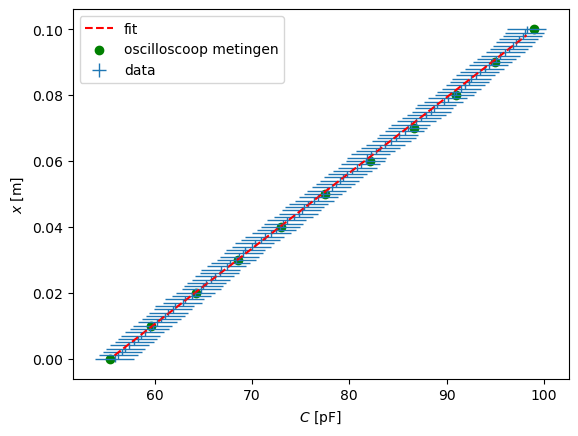

Onzekerheid: 0.0003 meter


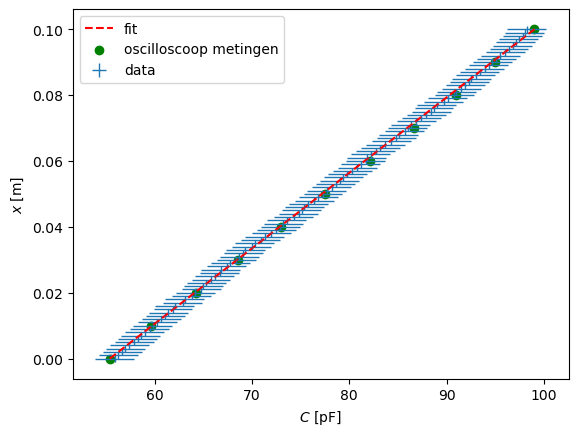

Onzekerheid van x is eerder bepaald via een lineaire fit op 0.3mm
Resolutie van arduino-metingen is 1 mm.


In [7]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
afstanden = np.linspace(0,100,101)*1e-3
capaciteiten = np.array([55.9,56.3,56.7,57.0,57.4,57.9,58.3,58.6,59.0,59.5,59.8,60.3,60.7,61.1,61.4,61.9,62.1,62.9,63.1,63.8,64.2,64.8,65.0,65.3,65.8,66.2,66.7,66.8,67.4,67.8,68.4,68.7,69.1,69.3,70.0,70.3,70.9,71.3,72.0,72.5,72.9,73.2,73.6,74.3,74.8,75.1,75.4,75.8,76.4,76.8,77.3,77.7,78.2,78.6,79.0,79.4,79.8,80.3,80.8,81.2,81.7,81.8,82.2,82.7,83.2,83.7,84.3,84.8,85.1,85.7,86.0,86.3,86.9,87.4,87.9,88.4,88.7,89.0,89.7,90.1,90.8,91.0,91.5,91.9,92.3,92.5,93.0,93.4,93.9,94.3,94.7,95.1,95.5,96.0,96.4,96.8,97.1,97.4,97.8,98.0,98.2])
oscilloscoopMetingen = np.array([55.4, 59.6, 64.3, 68.6, 73.0, 77.5, 82.1, 86.6, 91.0, 95.0, 99.0])

def func(x,a,b):
    y = a*x+b
    return y

popt,pcov = curve_fit(func,capaciteiten,afstanden)
xtest = np.linspace(np.min(capaciteiten),np.max(capaciteiten),100)
ytest = func(xtest,popt[0],popt[1])

plt.figure()                                                                                                           # 2 piocofarad onzekerheid komt van schommelingen van arduino
plt.errorbar(capaciteiten,afstanden,xerr=2,yerr=1e-3,linewidth=0,marker='.',markersize=0.5, elinewidth=1,label='data') # 1mm onzekerheid komt van 1mm streepjes op stuk plastic
plt.plot(xtest,ytest,'r--',label='fit')
plt.scatter(oscilloscoopMetingen, np.linspace(0, 100e-3, 11), color='green', label='oscilloscoop metingen')
plt.xlabel('$C$ [pF]')
plt.ylabel('$x$ [m]')
plt.legend()
plt.show()

print("Onzekerheid:", round(func(0.1, np.sqrt(pcov[0][0]), np.sqrt(pcov[1][1])), 4), 'meter')

# Aangepast is dat in de arduino software nu een afstand in meters wordt gereturned, omdat het systeem al dermate precies was dat er nog weinig iteratie nodig was


# Tweede manier met natuurkundige fit:

# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
afstanden = np.linspace(0,100,101)*1e-3
capaciteiten = np.array([55.9,56.3,56.7,57.0,57.4,57.9,58.3,58.6,59.0,59.5,59.8,60.3,60.7,61.1,61.4,61.9,62.1,62.9,63.1,63.8,64.2,64.8,65.0,65.3,65.8,66.2,66.7,66.8,67.4,67.8,68.4,68.7,69.1,69.3,70.0,70.3,70.9,71.3,72.0,72.5,72.9,73.2,73.6,74.3,74.8,75.1,75.4,75.8,76.4,76.8,77.3,77.7,78.2,78.6,79.0,79.4,79.8,80.3,80.8,81.2,81.7,81.8,82.2,82.7,83.2,83.7,84.3,84.8,85.1,85.7,86.0,86.3,86.9,87.4,87.9,88.4,88.7,89.0,89.7,90.1,90.8,91.0,91.5,91.9,92.3,92.5,93.0,93.4,93.9,94.3,94.7,95.1,95.5,96.0,96.4,96.8,97.1,97.4,97.8,98.0,98.2])
oscilloscoopMetingen = np.array([55.4, 59.6, 64.3, 68.6, 73.0, 77.5, 82.1, 86.6, 91.0, 95.0, 99.0])


def c_from_x(x, Er):
    A_pvc = (8e-2)*x
    A_air = A_tot-A_pvc
    C = C0 * ((A_pvc*Er+A_air*er_lucht)/(A_tot*er_lucht))
    return C

popt,pcov = curve_fit(c_from_x,afstanden,capaciteiten)
ytest = np.linspace(np.min(afstanden),np.max(afstanden),100)
xtest = c_from_x(ytest,popt[0])

plt.figure()                                                                                                           # 2 piocofarad onzekerheid komt van schommelingen van arduino
plt.errorbar(capaciteiten,afstanden,xerr=2,yerr=1e-3,linewidth=0,marker='.',markersize=0.5, elinewidth=1,label='data') # 1mm onzekerheid komt van 1mm streepjes op stuk plastic
plt.plot(xtest,ytest,'r--',label='fit')
plt.scatter(oscilloscoopMetingen, np.linspace(0, 100e-3, 11), color='green', label='oscilloscoop metingen')
plt.xlabel('$C$ [pF]')
plt.ylabel('$x$ [m]')
plt.legend()
plt.show()
print("Onzekerheid van x is eerder bepaald via een lineaire fit op 0.3mm")
print("Resolutie van arduino-metingen is 1 mm.")
# Aangepast is dat in de arduino software nu een afstand in meters wordt gereturned, omdat het systeem al dermate precies was dat er nog weinig iteratie nodig was